In [ ]:
!pip install skyfield


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.0/367.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 8.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from skyfield.api import load
from tqdm import tqdm

In [ ]:
# Preprocessing raw TLE data
TLE_FILENAME = "tle_history_38054.txt"
OUTPUT_CSV = "parsed_debris_data.csv"

print(f"Loading TLEs from {TLE_FILENAME}...")

try:
    satellites = load.tle_file(TLE_FILENAME)
except Exception as e:
    print(f"Error loading TLE file: {e}")
    print("Please check that the file name is correct and the file is not empty.")
    exit()

print(f"Successfully loaded {len(satellites)} TLE entries.")

data_list = []
for sat in satellites:
    model = sat.model

    time_jd = sat.epoch.tt

    data_list.append({
        'norad_id': model.satnum,
        'time_jd': time_jd,  # Julian Date
        'epoch_utc': sat.epoch.utc_iso(), # Human-readable time
        'inclination_deg': np.rad2deg(model.inclo), # Inclination
        'eccentricity': model.ecco,                 # Eccentricity
        'raan_deg': np.rad2deg(model.nodeo),        # Right Ascension (RAAN)
        'arg_perigee_deg': np.rad2deg(model.argpo), # Argument of Perigee
        'mean_anomaly_deg': np.rad2deg(model.mo),   # Mean Anomaly
        'mean_motion_rev_day': model.no_kozai * (1440.0 / (2 * np.pi)), # Mean Motion
        'bstar_drag': model.bstar                   # BSTAR Drag Term
    })
#Converting Our list to pandas dataframe
df = pd.DataFrame(data_list)

df = df.sort_values(by='time_jd').reset_index(drop=True)

df.to_csv(OUTPUT_CSV, index=False)

print(f"\nSuccessfully parsed and saved data to {OUTPUT_CSV}")
print("\n--- Data Head ---")
print(df.head())
print("\n--- Data Info ---")
df.info()

Loading TLEs from tle_history_38054.txt...
Successfully loaded 4464 TLE entries.

Successfully parsed and saved data to parsed_debris_data.csv

--- Data Head ---
   norad_id       time_jd             epoch_utc  inclination_deg  \
0     38054  2.455940e+06  2012-01-13T07:12:24Z          73.9578   
1     38054  2.455941e+06  2012-01-14T17:11:23Z          73.9583   
2     38054  2.455944e+06  2012-01-17T16:43:57Z          73.9574   
3     38054  2.455947e+06  2012-01-20T07:19:56Z          73.9555   
4     38054  2.455950e+06  2012-01-23T06:52:27Z          73.9529   

   eccentricity  raan_deg  arg_perigee_deg  mean_anomaly_deg  \
0      0.041689  125.9342           4.4675          355.9792   
1      0.041723  123.6948           1.8587          358.3796   
2      0.041730  118.9801         356.5401            3.2556   
3      0.041849  114.8525         351.7548            7.7247   
4      0.041809  110.1364         346.4579           12.6107   

   mean_motion_rev_day  bstar_drag  
0      

Loading data from parsed_debris_data.csv...
Data loaded. Generating comprehensive plots...
Displaying plots...


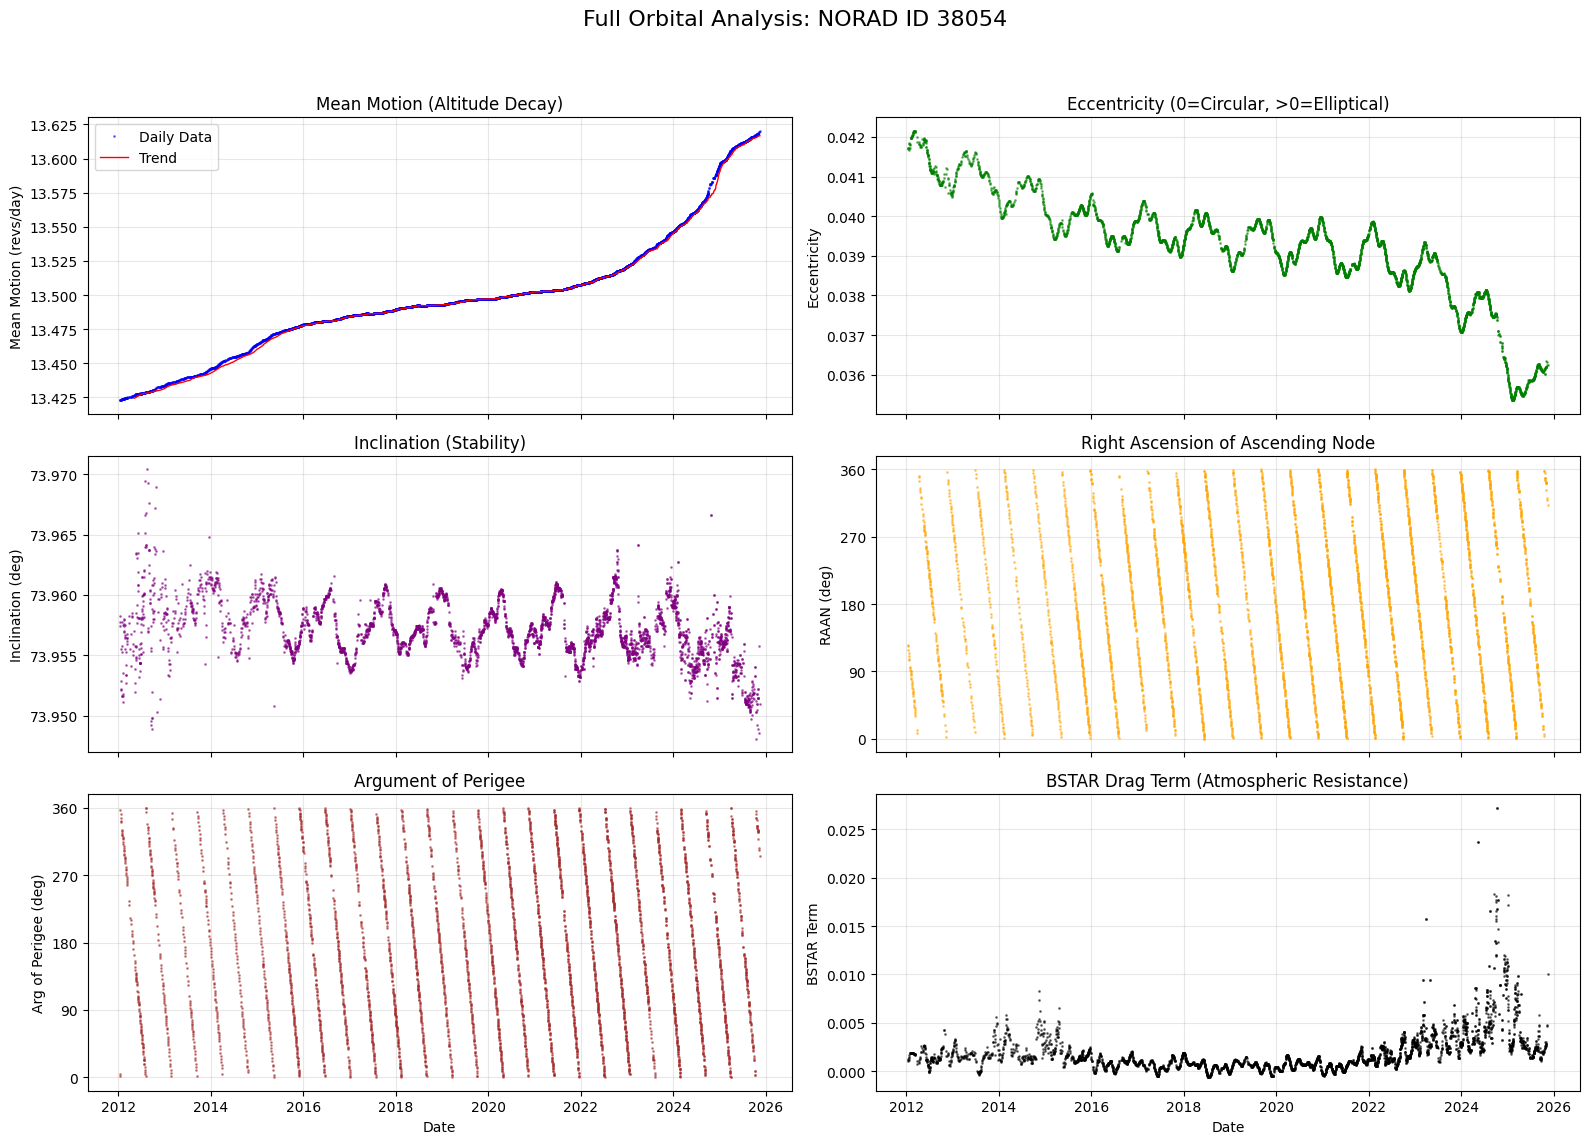

In [ ]:

CSV_FILENAME = "parsed_debris_data.csv"


print(f"Loading data from {CSV_FILENAME}...")
try:
    df = pd.read_csv(CSV_FILENAME)
except FileNotFoundError:
    print(f"ERROR: File not found: {CSV_FILENAME}")
    exit()

df['epoch_utc'] = pd.to_datetime(df['epoch_utc'])

print("Data loaded. Generating comprehensive plots...")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12), sharex=True)
fig.suptitle(f'Full Orbital Analysis: NORAD ID {df["norad_id"].iloc[0]}', fontsize=16)

ax = axes.flatten()

ax[0].plot(df['epoch_utc'], df['mean_motion_rev_day'], '.', markersize=2, color='blue', alpha=0.5, label='Daily Data')

ax[0].plot(df['epoch_utc'], df['mean_motion_rev_day'].rolling(window=50).mean(), 'r-', linewidth=1, label='Trend')
ax[0].set_ylabel('Mean Motion (revs/day)')
ax[0].set_title('Mean Motion (Altitude Decay)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(df['epoch_utc'], df['eccentricity'], '.', markersize=2, color='green', alpha=0.5)
ax[1].set_ylabel('Eccentricity')
ax[1].set_title('Eccentricity (0=Circular, >0=Elliptical)')
ax[1].grid(True, alpha=0.3)

ax[2].plot(df['epoch_utc'], df['inclination_deg'], '.', markersize=2, color='purple', alpha=0.5)
ax[2].set_ylabel('Inclination (deg)')
ax[2].set_title('Inclination (Stability)')
ax[2].grid(True, alpha=0.3)

ax[3].plot(df['epoch_utc'], df['raan_deg'], '.', markersize=2, color='orange', alpha=0.5)
ax[3].set_ylabel('RAAN (deg)')
ax[3].set_title('Right Ascension of Ascending Node')
ax[3].set_yticks([0, 90, 180, 270, 360])
ax[3].grid(True, alpha=0.3)

ax[4].plot(df['epoch_utc'], df['arg_perigee_deg'], '.', markersize=2, color='brown', alpha=0.5)
ax[4].set_ylabel('Arg of Perigee (deg)')
ax[4].set_xlabel('Date')
ax[4].set_title('Argument of Perigee')
ax[4].set_yticks([0, 90, 180, 270, 360])
ax[4].grid(True, alpha=0.3)

ax[5].plot(df['epoch_utc'], df['bstar_drag'], '.', markersize=2, color='black', alpha=0.5)
ax[5].set_ylabel('BSTAR Term')
ax[5].set_xlabel('Date')
ax[5].set_title('BSTAR Drag Term (Atmospheric Resistance)')
ax[5].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
print("Displaying plots...")
plt.show()

In [ ]:
# In this block we create the "hybrid training dataset". This dataset contains the errors in the spg4 predictions
TLE_FILENAME = "tle_history_38054.txt"
PARSED_DATA_CSV = "parsed_debris_data.csv"
OUTPUT_HYBRID_CSV = "hybrid_training_data.csv"

# Features to be used in our model training
FEATURES_TO_USE = [
    'mean_motion_rev_day',
    'eccentricity',
    'bstar_drag',
    'inclination_deg',
    'raan_deg',
    'arg_perigee_deg',
    'mean_anomaly_deg'
]

print(f"Loading raw TLEs from {TLE_FILENAME}...")
try:
    satellites = load.tle_file(TLE_FILENAME)
except Exception as e:
    print(f"Error loading TLE file: {e}")
    exit()

print(f"Loading parsed data from {PARSED_DATA_CSV}...")
try:
    df_parsed = pd.read_csv(PARSED_DATA_CSV)
except Exception as e:
    print(f"Error loading CSV file: {e}")
    exit()

df_parsed = df_parsed.sort_values(by='time_jd').reset_index(drop=True)

hybrid_data_list = []
print("Generating hybrid training data (calculating error vectors)...")

for i in tqdm(range(1, len(satellites))):

    sat_t0 = satellites[i-1]
    sat_t1 = satellites[i]
    t1_epoch = sat_t1.epoch

    predicted_pos = sat_t0.at(t1_epoch).position.km

    actual_pos = sat_t1.at(t1_epoch).position.km

    error_vector = actual_pos - predicted_pos

    features = df_parsed.loc[i-1]

    new_record = {}

    for col in FEATURES_TO_USE:
        new_record[col] = features[col]

    time_t0 = sat_t0.epoch.tt
    time_t1 = sat_t1.epoch.tt
    new_record['delta_t_days'] = time_t1 - time_t0

    new_record['error_x_km'] = error_vector[0]
    new_record['error_y_km'] = error_vector[1]
    new_record['error_z_km'] = error_vector[2]

    hybrid_data_list.append(new_record)

df_hybrid = pd.DataFrame(hybrid_data_list)

df_hybrid = df_hybrid.dropna()

df_hybrid.to_csv(OUTPUT_HYBRID_CSV, index=False)

print(f"\nSuccessfully created hybrid dataset with {len(df_hybrid)} records.")
print(f"Saved to {OUTPUT_HYBRID_CSV}")
print("\n--- New Dataset Head ---")
print(df_hybrid.head())

Loading raw TLEs from tle_history_38054.txt...
Loading parsed data from parsed_debris_data.csv...
Generating hybrid training data (calculating error vectors)...


100%|██████████| 4459/4459 [00:03<00:00, 1219.16it/s]



Successfully created hybrid dataset with 4459 records.
Saved to hybrid_training_data.csv

--- New Dataset Head ---
   mean_motion_rev_day  eccentricity  bstar_drag  inclination_deg  raan_deg  \
0            13.423022      0.041689    0.001298          73.9578  125.9342   
1            13.423043      0.041723    0.001216          73.9583  123.6948   
2            13.423091      0.041730    0.001100          73.9574  118.9801   
3            13.423163      0.041849    0.001162          73.9555  114.8525   
4            13.423265      0.041809    0.001378          73.9529  110.1364   

   arg_perigee_deg  mean_anomaly_deg  delta_t_days  error_x_km  error_y_km  \
0           4.4675          355.9792      1.415958    0.721631    0.154868   
1           1.8587          358.3796      2.980950    1.181095    0.593672   
2         356.5401            3.2556      2.608327   -0.704327   -1.156490   
3         351.7548            7.7247      2.980913   -1.691199   -0.254547   
4         346.4579 

Loading data from hybrid_training_data.csv...
Splitting data into train and test sets...
Training records: 3567, Test records: 892
Initializing and fitting scalers *only* on training data...
Data scaling complete.
Creating sequences with 30-day lookback...
X_train shape: (3537, 30, 8)
y_train shape: (3537, 3)
X_test shape: (862, 30, 8)
y_test shape: (862, 3)
Building hybrid LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0671 - val_loss: 0.0191
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0092 - val_loss: 0.0111
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0064 - val_loss: 0.0104
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0049 - val_loss: 0.0101
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0040 - val_loss: 0.0102
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0036 - val_loss: 0.0102
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0033 - val_loss: 0.0104
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0034 - val_loss: 0.0105
Epoch 9/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0034 - val_loss: 0.0104
Epoch 10/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0029 - val_loss: 0.0104
Epoch 11/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0028 - val_loss: 0.0102
E


Training complete. Model saved as hybrid_residual_lstm.h5
Plotting training loss...


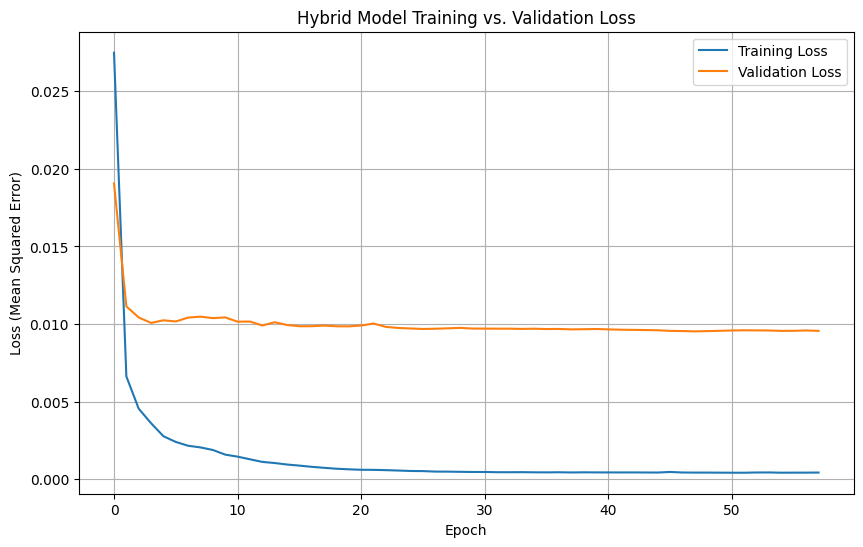

In [ ]:
# This is where we train our hybrid LSTM model

HYBRID_CSV = "hybrid_training_data.csv"
OUTPUT_HYBRID_MODEL = "hybrid_residual_lstm.h5"

FEATURES_TO_USE = [
    'mean_motion_rev_day', 'eccentricity', 'bstar_drag', 'inclination_deg',
    'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg', 'delta_t_days'
]
TARGETS_TO_PREDICT = [
    'error_x_km', 'error_y_km', 'error_z_km'
]
LOOKBACK_DAYS = 30
TRAIN_SPLIT_RATIO = 0.8

print(f"Loading data from {HYBRID_CSV}...")
df = pd.read_csv(HYBRID_CSV)
df = df.dropna()

print("Splitting data into train and test sets...")

split_index = int(len(df) * TRAIN_SPLIT_RATIO)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"Training records: {len(df_train)}, Test records: {len(df_test)}")
print("Initializing and fitting scalers *only* on training data...")

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

feature_scaler.fit(df_train[FEATURES_TO_USE])
target_scaler.fit(df_train[TARGETS_TO_PREDICT])

scaled_features_train = feature_scaler.transform(df_train[FEATURES_TO_USE])
scaled_targets_train = target_scaler.transform(df_train[TARGETS_TO_PREDICT])

scaled_features_test = feature_scaler.transform(df_test[FEATURES_TO_USE])
scaled_targets_test = target_scaler.transform(df_test[TARGETS_TO_PREDICT])

print("Data scaling complete.")

def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(len(features) - lookback):
        X.append(features[i:(i + lookback)])
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

print(f"Creating sequences with {LOOKBACK_DAYS}-day lookback...")
X_train, y_train = create_sequences(scaled_features_train, scaled_targets_train, LOOKBACK_DAYS)
X_test, y_test = create_sequences(scaled_features_test, scaled_targets_test, LOOKBACK_DAYS)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("Building hybrid LSTM model...")
input_shape = (X_train.shape[1], X_train.shape[2])
num_outputs = y_train.shape[1]

model = Sequential()

model.add(Bidirectional(LSTM(units=75, input_shape=input_shape)))
model.add(Dropout(0.3))
model.add(Dense(units=25))
model.add(Dense(units=num_outputs))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
    callbacks=[early_stopper]
)

model.save(OUTPUT_HYBRID_MODEL)
print(f"\nTraining complete. Model saved as {OUTPUT_HYBRID_MODEL}")

print("Plotting training loss...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hybrid Model Training vs. Validation Loss')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

HYBRID_CSV = "hybrid_training_data.csv"
OUTPUT_RNN_MODEL = "hybrid_residual_rnn.h5"

FEATURES_TO_USE = [
    'mean_motion_rev_day', 'eccentricity', 'bstar_drag', 'inclination_deg',
    'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg', 'delta_t_days'
]
TARGETS_TO_PREDICT = [
    'error_x_km', 'error_y_km', 'error_z_km'
]
LOOKBACK_DAYS = 7
TRAIN_SPLIT_RATIO = 0.8

print(f"Loading data from {HYBRID_CSV}...")
df = pd.read_csv(HYBRID_CSV)
df = df.dropna()

print("Splitting data into train and test sets...")
split_index = int(len(df) * TRAIN_SPLIT_RATIO)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print("Fitting scalers on training data...")
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

feature_scaler.fit(df_train[FEATURES_TO_USE])
target_scaler.fit(df_train[TARGETS_TO_PREDICT])

scaled_features_train = feature_scaler.transform(df_train[FEATURES_TO_USE])
scaled_targets_train = target_scaler.transform(df_train[TARGETS_TO_PREDICT])
scaled_features_test = feature_scaler.transform(df_test[FEATURES_TO_USE])
scaled_targets_test = target_scaler.transform(df_test[TARGETS_TO_PREDICT])

def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(len(features) - lookback):
        X.append(features[i:(i + lookback)])
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

print("Creating sequences...")
X_train, y_train = create_sequences(scaled_features_train, scaled_targets_train, LOOKBACK_DAYS)
X_test, y_test = create_sequences(scaled_features_test, scaled_targets_test, LOOKBACK_DAYS)

print("Building Simple RNN model...")
input_shape = (X_train.shape[1], X_train.shape[2])
num_outputs = y_train.shape[1]

model = Sequential()

model.add(SimpleRNN(units=75, input_shape=input_shape))


model.add(Dropout(0.3))
model.add(Dense(units=25))
model.add(Dense(units=num_outputs))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

print("\nStarting RNN training...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
    callbacks=[early_stopper]
)

model.save(OUTPUT_RNN_MODEL)
print(f"\nTraining complete. Model saved as {OUTPUT_RNN_MODEL}")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Training vs. Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

Loading data from hybrid_training_data.csv...
Initializing and fitting scalers *only* on training data...
Creating test sequences (lookback=30)...
X_test shape: (862, 30, 8)
y_test_scaled shape: (862, 3)
Loading hybrid model from hybrid_residual_lstm.h5...
Error loading model: name 'load_model' is not defined
Making predictions on test data...
Un-scaling vectors to get real-world error (km)...
Calculating final mean errors...

     FINAL PROJECT RESULTS     
  Baseline SGP4-Only Mean Error: 1.660 km
   Hybrid (SGP4+AI) Mean Error: 2.099 km
---
      Percentage Improvement: -26.48%

Saving detailed error breakdown to final_error_comparison.csv...
Successfully saved comparison file to final_error_comparison.csv.

Generating error distribution plots...


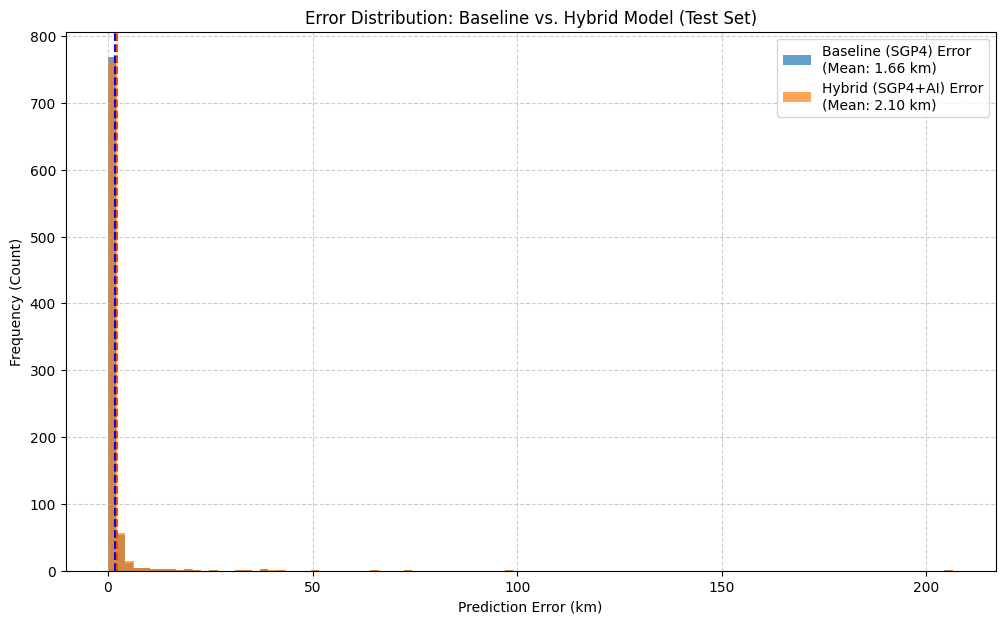

In [ ]:

HYBRID_CSV = "hybrid_training_data.csv"
HYBRID_MODEL = "hybrid_residual_lstm.h5"
OUTPUT_COMPARISON_CSV = "final_error_comparison.csv"

FEATURES_TO_USE = [
    'mean_motion_rev_day', 'eccentricity', 'bstar_drag', 'inclination_deg',
    'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg', 'delta_t_days'
]
TARGETS_TO_PREDICT = [
    'error_x_km', 'error_y_km', 'error_z_km'
]
LOOKBACK_DAYS = 30
TRAIN_SPLIT_RATIO = 0.8

print(f"Loading data from {HYBRID_CSV}...")
df = pd.read_csv(HYBRID_CSV)

split_index = int(len(df) * TRAIN_SPLIT_RATIO)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print("Initializing and fitting scalers *only* on training data...")

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

feature_scaler.fit(df_train[FEATURES_TO_USE])
target_scaler.fit(df_train[TARGETS_TO_PREDICT])

scaled_features_train = feature_scaler.transform(df_train[FEATURES_TO_USE])
scaled_targets_train = target_scaler.transform(df_train[TARGETS_TO_PREDICT])

scaled_features_test = feature_scaler.transform(df_test[FEATURES_TO_USE])
scaled_targets_test = target_scaler.transform(df_test[TARGETS_TO_PREDICT])

def create_sequences(features, targets, lookback):
    X, y = [], []
    for i in range(len(features) - lookback):
        X.append(features[i:(i + lookback)])
        y.append(targets[i + lookback])
    return np.array(X), np.array(y)

print(f"Creating test sequences (lookback={LOOKBACK_DAYS})...")
X_test, y_test_scaled = create_sequences(
    scaled_features_test, scaled_targets_test, LOOKBACK_DAYS
)

print(f"X_test shape: {X_test.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")

print(f"Loading hybrid model from {HYBRID_MODEL}...")
try:
    model = load_model(HYBRID_MODEL)
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

print("Making predictions on test data...")
y_pred_scaled = model.predict(X_test, verbose=0)

print("Un-scaling vectors to get real-world error (km)...")

y_pred_unscaled_km = target_scaler.inverse_transform(y_pred_scaled)

y_test_unscaled_km = target_scaler.inverse_transform(y_test_scaled)

print("Calculating final mean errors...")

errors_km_baseline = np.linalg.norm(y_test_unscaled_km, axis=1)
mean_baseline_error = np.mean(errors_km_baseline)

error_vec_hybrid = y_test_unscaled_km - y_pred_unscaled_km
errors_km_hybrid = np.linalg.norm(error_vec_hybrid, axis=1)
mean_hybrid_error = np.mean(errors_km_hybrid)

improvement = ((mean_baseline_error - mean_hybrid_error) / mean_baseline_error) * 100

print("\n" + "="*40)
print("     FINAL PROJECT RESULTS     ")
print("="*40)
print(f"  Baseline SGP4-Only Mean Error: {mean_baseline_error:.3f} km")
print(f"   Hybrid (SGP4+AI) Mean Error: {mean_hybrid_error:.3f} km")
print("---")
print(f"      Percentage Improvement: {improvement:.2f}%")
print("="*40)

print(f"\nSaving detailed error breakdown to {OUTPUT_COMPARISON_CSV}...")

output_data = {
    'baseline_error_x_km': y_test_unscaled_km[:, 0],
    'baseline_error_y_km': y_test_unscaled_km[:, 1],
    'baseline_error_z_km': y_test_unscaled_km[:, 2],
    'baseline_total_error_km': errors_km_baseline,

    'ai_predicted_error_x_km': y_pred_unscaled_km[:, 0],
    'ai_predicted_error_y_km': y_pred_unscaled_km[:, 1],
    'ai_predicted_error_z_km': y_pred_unscaled_km[:, 2],

    'hybrid_error_x_km': error_vec_hybrid[:, 0],
    'hybrid_error_y_km': error_vec_hybrid[:, 1],
    'hybrid_error_z_km': error_vec_hybrid[:, 2],
    'hybrid_total_error_km': errors_km_hybrid
}

df_output = pd.DataFrame(output_data)

df_output.to_csv(OUTPUT_COMPARISON_CSV, index=False)
print(f"Successfully saved comparison file to {OUTPUT_COMPARISON_CSV}.")

print("\nGenerating error distribution plots...")
plt.figure(figsize=(12, 7))
plt.hist(errors_km_baseline, bins=100, alpha=0.7,
         label=f'Baseline (SGP4) Error\n(Mean: {mean_baseline_error:.2f} km)')
plt.hist(errors_km_hybrid, bins=100, alpha=0.7,
         label=f'Hybrid (SGP4+AI) Error\n(Mean: {mean_hybrid_error:.2f} km)')

plt.xlabel('Prediction Error (km)')
plt.ylabel('Frequency (Count)')
plt.title('Error Distribution: Baseline vs. Hybrid Model (Test Set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(mean_baseline_error, color='blue', linestyle='--')
plt.axvline(mean_hybrid_error, color='orangered', linestyle='--')
plt.show()